In [41]:
import pandas as pd
from tqdm.auto import tqdm
import nltk
from nltk.tokenize import word_tokenize
import spacy
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

In [18]:
df_reactions = pd.read_parquet("../reactions/reactions.parquet")

## Calcul du score

In [19]:
df_reactions_clean = df_reactions[df_reactions['creative'].isin([True, False])].copy()

df_reactions_clean['creative'] = df_reactions_clean['creative'].astype(int)

df_reactions_sample = df_reactions_clean.sample(n=5000)

print("Répartition des votes dans l'échantillon :")
print(df_reactions_sample['creative'].value_counts())

Répartition des votes dans l'échantillon :
creative
0    4650
1     350
Name: count, dtype: int64


### Famille A : Nouveauté

In [4]:
nltk.download('punkt', quiet=True)

def calculate_mattr(text, window_size=50):
    """
    Calcule le MATTR (Moving-Average Type-Token Ratio).
    Plus le score est proche de 1, plus le vocabulaire est varié.
    """
    tokens = word_tokenize(text.lower())
    
    # Si le texte est plus court que la fenêtre, on renvoie un TTR simple
    if len(tokens) <= window_size:
        if not tokens: return 0.0
        return len(set(tokens)) / len(tokens)
    
    ttr_sum = 0
    num_windows = len(tokens) - window_size + 1
    
    for i in range(num_windows):
        window = tokens[i:i + window_size]
        ttr = len(set(window)) / window_size
        ttr_sum += ttr
        
    return ttr_sum / num_windows

In [5]:
tqdm.pandas(desc="Calcul de la Nouveauté")
novelty_raw = df_reactions_sample['response_content'].progress_apply(calculate_mattr)

Calcul de la Nouveauté:   0%|          | 0/5000 [00:00<?, ?it/s]

### Famille B : Valeur/Cohérence

In [6]:
nlp = spacy.load("fr_core_news_md", disable=["ner", "parser"])
nlp.add_pipe("sentencizer") # Permet de découper en phrases rapidement

def calculate_local_coherence(text):
    """
    Calcule la cohérence locale moyenne d'un texte en mesurant
    la similarité cosinus entre les phrases consécutives.
    """
    if not isinstance(text, str) or not text.strip():
        return 0.0
        
    doc = nlp(text)
    sentences = list(doc.sents)
    
    # Si le texte ne contient qu'une seule phrase, il est techniquement cohérent avec lui-même
    if len(sentences) < 2:
        return 1.0 
        
    similarities = []
    
    for i in range(len(sentences) - 1):
        vec1 = sentences[i].vector
        vec2 = sentences[i+1].vector
        
        if np.linalg.norm(vec1) == 0 or np.linalg.norm(vec2) == 0:
            similarities.append(0.0)
            continue
            
        sim = cosine_similarity([vec1], [vec2])[0][0]
        similarities.append(sim)
        
    return np.mean(similarities)

In [7]:
tqdm.pandas(desc="Calcul de la Cohérence")
coherence_raw = df_reactions_sample['response_content'].progress_apply(calculate_local_coherence)

Calcul de la Cohérence:   0%|          | 0/5000 [00:00<?, ?it/s]

### Famille C : Surprise

In [8]:
def calculate_divergent_thinking_spacy(text):
    """
    Mesure les sauts sémantiques entre les mots importants d'une phrase.
    Utilise les vecteurs SpaCy déjà en mémoire.
    """
    if not isinstance(text, str) or not text.strip():
        return 0.0
        
    doc = nlp(text)
    
    # On ne garde que les mots porteurs de sens (pas de ponctuation, pas de mots de liaison "le", "de", etc.)
    # et on vérifie qu'ils ont bien un vecteur connu par spaCy
    mots_cles = [token for token in doc if token.is_alpha and not token.is_stop and token.has_vector]
    
    if len(mots_cles) < 2:
        return 0.0
        
    distances = []
    
    for i in range(len(mots_cles) - 1):
        vec1 = mots_cles[i].vector
        vec2 = mots_cles[i+1].vector
        
        # Similarité cosinus (retourne une valeur entre -1 et 1)
        sim = cosine_similarity([vec1], [vec2])[0][0]
        # On convertit la similarité en distance (plus c'est proche de 1, plus c'est éloigné sémantiquement)
        distance = 1.0 - sim 
        distances.append(distance)
        
    return np.mean(distances)

In [9]:
texte_banal = "Le chat mange la souris dans le jardin."
texte_surprenant = "Abraracourcix s'enfourne une williams."

print(f"Surprise texte banal : {calculate_divergent_thinking_spacy(texte_banal):.3f}")
print(f"Surprise texte surprenant : {calculate_divergent_thinking_spacy(texte_surprenant):.3f}")

Surprise texte banal : 0.731
Surprise texte surprenant : 1.060


In [10]:
tqdm.pandas(desc="Calcul de la Surprise")
surprise_raw = df_reactions_sample['response_content'].progress_apply(calculate_divergent_thinking_spacy)

Calcul de la Surprise:   0%|          | 0/5000 [00:00<?, ?it/s]

### Creativity Index

#### From previous cells

In [ ]:
df_reactions_sample['novelty_raw'] = novelty_raw
df_reactions_sample['coherence_raw'] = coherence_raw
df_reactions_sample['surprise_raw'] = surprise_raw

NameError: name 'novelty_raw' is not defined

In [12]:
# Normalization
scaler = MinMaxScaler()

metrics_raw = ['novelty_raw', 'coherence_raw', 'surprise_raw']
metrics_norm = ['novelty_norm', 'coherence_norm', 'surprise_norm']

df_reactions_sample[metrics_norm] = scaler.fit_transform(df_reactions_sample[metrics_raw])

In [28]:
df_metrics = df_reactions_sample[["id"]]
df_metrics["novelty_mattr"] = df_reactions_sample.novelty_norm
df_metrics["local_coherence"] = df_reactions_sample.coherence_norm
df_metrics["divergent_thinking"] = df_reactions_sample.surprise_norm


save_path = "reactions_sample_5000_with_metrics.parquet"
df_metrics.to_parquet(save_path, index=False)

print(f"Sauvegarde réussie ! {len(df_metrics)} lignes stockées dans '{save_path}'.")

Sauvegarde réussie ! 5000 lignes stockées dans 'reactions_sample_5000_with_metrics.parquet'.


#### From saved .parquet

In [21]:
df_reactions_metrics = pd.read_parquet("reactions_sample_5000_with_metrics.parquet")
df_reactions_ngram = pd.read_parquet("reactions_with_ngram.parquet")

In [27]:
df_reactions_sample = pd.merge(
    df_reactions_clean,
    df_reactions_metrics,
    on='id',
    how='inner'
)
df_reactions_sample = pd.merge(
    df_reactions_sample,
    df_reactions_ngram,
    on='id',
    how='inner'
)

#### Creative Index computation

**Approche 1 : Fonction de calcul manuel**

In [44]:
def evaluate_manual_ci(df, weight_novelty, weight_coherence, weight_surprise, novelty='novelty_norm', coherence='coherence_norm', surprise='surprise_norm'):
    df['CI_manual'] = (weight_novelty * df[novelty] + 
                       weight_coherence * df[coherence] + 
                       weight_surprise * df[surprise])
    
    corr, p_val = pearsonr(df['CI_manual'], df.creative)
    
    auc = roc_auc_score(df.creative, df['CI_manual'])
    
    print(f"Évaluation Manuelle (Poids: N={weight_novelty}, C={weight_coherence}, S={weight_surprise}) ---")
    print(f"Corrélation de Pearson : {corr:.3f} (p-value: {p_val:.4f})")
    print(f"Score ROC-AUC          : {auc:.3f}\n")


    plt.figure(figsize=(7, 6))
    
    # Calcul des points de la courbe
    fpr, tpr, thresholds = roc_curve(df.creative, df['CI_manual'])
    
    # Tracé de la courbe du modèle
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {auc:.3f})')
    
    # Tracé de la ligne de hasard (diagonale)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    
    # Mise en forme du graphique
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=11)
    plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=11)
    plt.title('Capacité de discrimination de l\'Index (Courbe ROC)', fontsize=13, pad=15)
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(alpha=0.3)
    
    # Affichage
    plt.tight_layout()
    plt.show()
    
    return df

MATTR + Local Coherence + Divergent Thinking
Évaluation Manuelle (Poids: N=0.3, C=0.2, S=0.5) ---
Corrélation de Pearson : 0.038 (p-value: 0.0071)
Score ROC-AUC          : 0.562



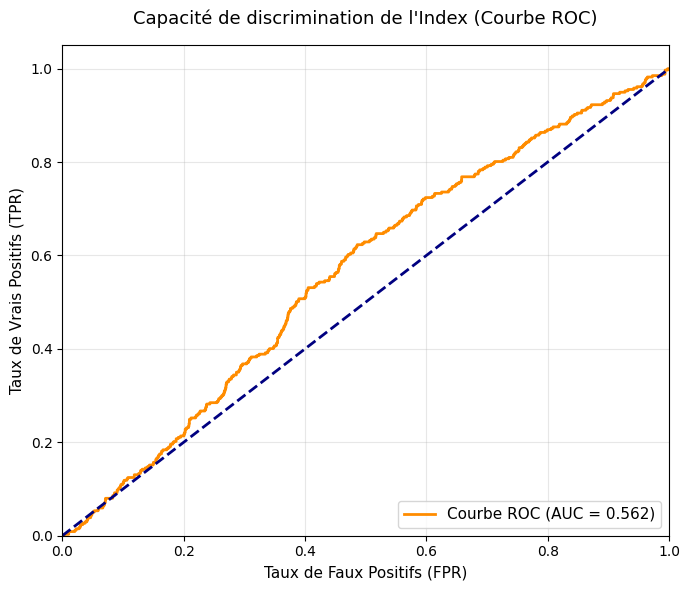

N-GRAM + Local Coherence + Divergent Thinking
Évaluation Manuelle (Poids: N=0.3, C=0.2, S=0.5) ---
Corrélation de Pearson : 0.055 (p-value: 0.0001)
Score ROC-AUC          : 0.586



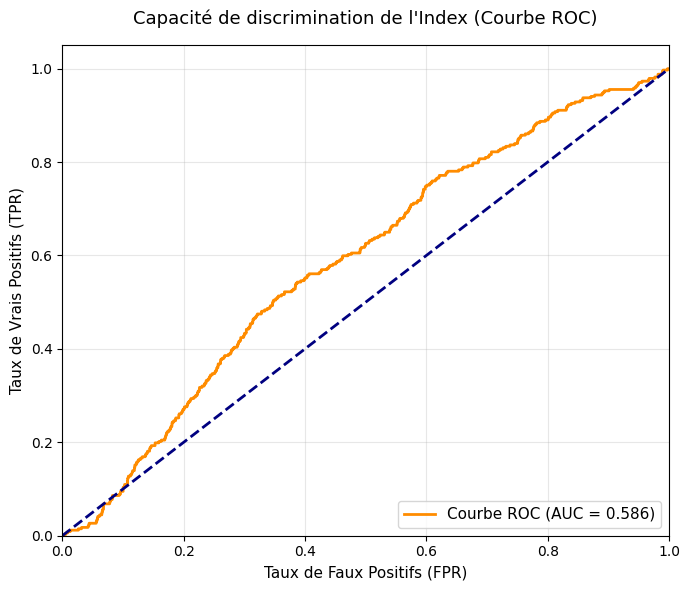

In [45]:
print("MATTR + Local Coherence + Divergent Thinking")
df_reactions_sample = evaluate_manual_ci(df_reactions_sample, 0.3, 0.2, 0.5, 'novelty_mattr', 'local_coherence', 'divergent_thinking')

print("N-GRAM + Local Coherence + Divergent Thinking")
df_reactions_sample = evaluate_manual_ci(df_reactions_sample, 0.3, 0.2, 0.5, 'ngram_rarity', 'local_coherence', 'divergent_thinking')

In [35]:
def grid_search_ci_weights(df, novelty='novelty_norm', coherence='coherence_norm', surprise='surprise_norm', step=0.1):
    best_auc = 0
    best_weights_auc = (0, 0, 0)
    
    results = []
    labels = df.creative
    
    for w_n in np.arange(0.0, 1.01, step):
        for w_c in np.arange(0.0, 1.01 - w_n + (step/2), step):
            w_s = 1.0 - w_n - w_c
            
            w_n, w_c, w_s = round(w_n, 2), round(w_c, 2), round(w_s, 2)
            
            if w_s < 0: continue
                
            ci_scores = (w_n * df[novelty] + 
                         w_c * df[coherence] + 
                         w_s * df[surprise])
            
            auc = roc_auc_score(labels, ci_scores)
            corr, _ = pearsonr(ci_scores, labels)
            
            results.append({
                'Poids Nouveauté': w_n, 
                'Poids Cohérence': w_c, 
                'Poids Surprise': w_s, 
                'ROC-AUC': auc, 
                'Pearson': corr
            })
            
            if auc > best_auc:
                best_auc = auc
                best_weights_auc = (w_n, w_c, w_s)
                
    print("RÉSULTATS DE LA GRID SEARCH")
    print(f"Meilleur ROC-AUC trouvé : {best_auc:.3f}")
    print(f"Combinaison idéale -> N={best_weights_auc[0]}, C={best_weights_auc[1]}, S={best_weights_auc[2]}")
    
    df_results = pd.DataFrame(results).sort_values(by='ROC-AUC', ascending=False)
    return df_results

In [36]:
print("MATTR + Local Coherence + Divergent Thinking")
df_grid_results = grid_search_ci_weights(df_reactions_sample, 'novelty_mattr', 'local_coherence', 'divergent_thinking', step=0.05)
print("\nTop 5 des combinaisons :")
print(df_grid_results.head(5).to_string(index=False))

print("N-GRAM + Local Coherence + Divergent Thinking")
df_grid_results = grid_search_ci_weights(df_reactions_sample, 'ngram_rarity', 'local_coherence', 'divergent_thinking', step=0.05)
print("\nTop 5 des combinaisons :")
print(df_grid_results.head(5).to_string(index=False))

MATTR + Local Coherence + Divergent Thinking
RÉSULTATS DE LA GRID SEARCH
Meilleur ROC-AUC trouvé : 0.618
Combinaison idéale -> N=0.1, C=0.0, S=0.9

Top 5 des combinaisons :
 Poids Nouveauté  Poids Cohérence  Poids Surprise  ROC-AUC  Pearson
            0.10              0.0            0.90 0.617788 0.087620
            0.05              0.0            0.95 0.617552 0.087836
            0.00              0.0            1.00 0.617091 0.087629
            0.15              0.0            0.85 0.616943 0.086855
            0.20              0.0            0.80 0.615576 0.085413
N-GRAM + Local Coherence + Divergent Thinking
RÉSULTATS DE LA GRID SEARCH
Meilleur ROC-AUC trouvé : 0.622
Combinaison idéale -> N=0.3, C=0.0, S=0.7

Top 5 des combinaisons :
 Poids Nouveauté  Poids Cohérence  Poids Surprise  ROC-AUC  Pearson
            0.30              0.0            0.70 0.621701 0.087285
            0.25              0.0            0.75 0.621694 0.088677
            0.20              0.0        

**Approche 2 : Régression Logistique**

In [37]:
def find_optimal_weights(df, novelty='novelty_norm', coherence='coherence_norm', surprise='surprise_norm'):
    """
    Utilise une régression logistique pour apprendre les poids optimaux depuis les votes.
    """
    X = df[[novelty, coherence, surprise]]
    y = df.creative
    

    model = LogisticRegression(class_weight='balanced')
    model.fit(X, y)
    
    coeffs = model.coef_[0]
    

    coeffs_abs_sum = np.sum(np.abs(coeffs))
    optimal_weights = coeffs / coeffs_abs_sum
    
    print(f"Poids Optimaux trouvés par Régression Logistique")
    print(f"Poids Nouveauté (MATTR)       : {optimal_weights[0]:.3f}  (Coeff brut: {coeffs[0]:.2f})")
    print(f"Poids Cohérence (SpaCy)       : {optimal_weights[1]:.3f}  (Coeff brut: {coeffs[1]:.2f})")
    print(f"Poids Surprise (Divergence)   : {optimal_weights[2]:.3f}  (Coeff brut: {coeffs[2]:.2f})")
    
    df['CI_optimal'] = model.predict_proba(X)[:, 1]
    
    auc_opt = roc_auc_score(y, df['CI_optimal'])
    print(f"Score ROC-AUC avec poids opti : {auc_opt:.3f}")
    
    return df, optimal_weights

In [39]:
print("MATTR + Local Coherence + Divergent Thinking")
df_reactions_sample, best_weights = find_optimal_weights(df_reactions_sample, 'novelty_mattr', 'local_coherence', 'divergent_thinking')

print("\nN-GRAM + Local Coherence + Divergent Thinking")
df_reactions_sample, best_weights = find_optimal_weights(df_reactions_sample, 'ngram_rarity', 'local_coherence', 'divergent_thinking')

MATTR + Local Coherence + Divergent Thinking
Poids Optimaux trouvés par Régression Logistique
Poids Nouveauté (MATTR)       : 0.012  (Coeff brut: 0.07)
Poids Cohérence (SpaCy)       : -0.146  (Coeff brut: -0.85)
Poids Surprise (Divergence)   : 0.842  (Coeff brut: 4.87)
Score ROC-AUC avec poids opti : 0.620

N-GRAM + Local Coherence + Divergent Thinking
Poids Optimaux trouvés par Régression Logistique
Poids Nouveauté (MATTR)       : 0.150  (Coeff brut: 0.93)
Poids Cohérence (SpaCy)       : -0.138  (Coeff brut: -0.85)
Poids Surprise (Divergence)   : 0.712  (Coeff brut: 4.38)
Score ROC-AUC avec poids opti : 0.625


On obtient des résultats très médiocres. Cela peut s'expliquer par un choix de metriques peu représentatives (métriques plus simple pour pouvoir être calculées en un temps raisonnable).

La métrique de surprise semble être celle représentant le mieux la créativité, alors que les deux autres ont des même des influences faibles.

Pour la métrique de cohérence, son poids calculé avec la régression logistique, cela reste logique car le score est élevé quand on a une forte cohérence entre les phrases, ce qui peut limiter la créativité.

On est aussi limité sur la comparaison avec la vérité terrain (Seulement 1% des échantillons calculé avec un temps de calcul de plus de 10 minutes, sur environ 10% du dataset).